# PyTorch Lightning — A Complete Guided Tutorial

PyTorch Lightning is a lightweight wrapper around PyTorch that removes boilerplate code while keeping you in full control of your model. Think of it as **organized PyTorch** — the same math, the same tensors, but with a clean structure that scales from a laptop to a GPU cluster without changing your code.

### What you will learn

| Topic | What it covers |
|---|---|
| `LightningModule` | How to structure your model, loss, and optimizer in one class |
| `LightningDataModule` | How to organize data loading, splitting, and transforms |
| `Trainer` | How to run training, validation, and testing with one call |
| Callbacks | Early stopping, model checkpointing, and custom hooks |
| Schedulers | Learning rate scheduling tied to the training loop |
| Logging | Tracking metrics in a structured way |
| Reproducibility | Seeds, determinism, and best practices |

### The task
We'll classify handwritten digits using the **MNIST** dataset — a classic benchmark that is simple enough to focus on the framework rather than the problem.

> **Prerequisite:** You should be comfortable with basic PyTorch (tensors, `nn.Module`, `optim`). This tutorial focuses on *how Lightning wraps those concepts*, not on explaining them from scratch.

---
## Step 0 — Installation

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("PyTorch version     :", torch.__version__)
print("Lightning version   :", pl.__version__)
print("GPU available       :", torch.cuda.is_available())

PyTorch version     : 2.8.0+cu128
Lightning version   : 2.6.0
GPU available       : True


---
## Step 1 — Reproducibility

Before anything else, set a global seed. Lightning provides a convenience function that seeds Python, NumPy, and PyTorch all at once — including CUDA if available.

**Why this matters:** without a fixed seed, every run produces different weight initializations and data shuffling, making it impossible to compare experiments fairly.

In [2]:
pl.seed_everything(42, workers=True)
# workers=True also seeds the DataLoader worker processes

Seed set to 42


42

---
## Step 2 — LightningDataModule

A `LightningDataModule` is a self-contained object that handles everything related to data:
- Downloading
- Preprocessing and transforms
- Splitting into train / val / test
- Creating `DataLoader`s

### Why use it?
Without it, data logic is usually scattered across your script. The DataModule makes it **portable** — you can reuse the same data setup across different models and share it with teammates.

### The key methods

| Method | When it runs | What it does |
|---|---|---|
| `prepare_data()` | Once, on a single process | Download, tokenize — anything that writes to disk |
| `setup(stage)` | Once per process | Load data into memory, split, apply transforms |
| `train_dataloader()` | Every epoch | Returns the training `DataLoader` |
| `val_dataloader()` | Every epoch | Returns the validation `DataLoader` |
| `test_dataloader()` | When you call `trainer.test()` | Returns the test `DataLoader` |

In [3]:
class MNISTDataModule(pl.LightningDataModule):
    """
    Encapsulates all data logic for MNIST.
    
    Args:
        data_dir   : where to download/cache the dataset
        batch_size : number of samples per batch
        num_workers: parallel workers for data loading (0 = main process only)
        val_split  : fraction of training data to use for validation
    """
    def __init__(self, data_dir='./data', batch_size=64, num_workers=2, val_split=0.2):
        super().__init__()
        self.data_dir   = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.val_split  = val_split

        # Define transforms: convert PIL image to tensor, then normalize
        # Mean and std are pre-computed statistics for MNIST
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.1307,), std=(0.3081,))
        ])

    def prepare_data(self):
        # Called once — only downloads data, never assigns state (self.x = ...)
        # because this runs on a single GPU/process in multi-GPU setups
        datasets.MNIST(self.data_dir, train=True,  download=True)
        datasets.MNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        # Called on every GPU process — safe to assign self.x here
        # stage can be 'fit', 'validate', 'test', or 'predict'
        if stage == 'fit' or stage is None:
            full_train = datasets.MNIST(self.data_dir, train=True, transform=self.transform)
            val_size   = int(len(full_train) * self.val_split)
            train_size = len(full_train) - val_size
            # random_split uses the global seed set by pl.seed_everything
            self.mnist_train, self.mnist_val = random_split(full_train, [train_size, val_size])

        if stage == 'test' or stage is None:
            self.mnist_test = datasets.MNIST(self.data_dir, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(
            self.mnist_train,
            batch_size=self.batch_size,
            shuffle=True,          # Always shuffle training data
            num_workers=self.num_workers,
            pin_memory=True        # Faster GPU transfers
        )

    def val_dataloader(self):
        return DataLoader(
            self.mnist_val,
            batch_size=self.batch_size,
            shuffle=False,         # Never shuffle validation/test
            num_workers=self.num_workers,
            pin_memory=True
        )

    def test_dataloader(self):
        return DataLoader(
            self.mnist_test,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True
        )


# Quick sanity check
dm = MNISTDataModule(batch_size=512, num_workers=8)
dm.prepare_data()
dm.setup()

batch = next(iter(dm.train_dataloader()))
images, labels = batch
print(f"Batch image shape : {images.shape}  (batch, channels, height, width)")
print(f"Batch label shape : {labels.shape}")
print(f"Train size        : {len(dm.mnist_train)}")
print(f"Val size          : {len(dm.mnist_val)}")
print(f"Test size         : {len(dm.mnist_test)}")

Batch image shape : torch.Size([512, 1, 28, 28])  (batch, channels, height, width)
Batch label shape : torch.Size([512])
Train size        : 48000
Val size          : 12000
Test size         : 10000


In [4]:
print("CPU cores        :", os.cpu_count())
print("GPU              :", torch.cuda.get_device_name(0))
print("CUDA version     :", torch.version.cuda)
print("Batch size       :", dm.batch_size)
print("Num workers      :", dm.num_workers)
print("Persistent workers:", True)  # are you setting this?

# Time just the dataloader, no model involved
import time
loader = dm.train_dataloader()
t0 = time.time()
for i, batch in enumerate(loader):
    if i == 10: break
print(f"10 batches loaded in {time.time() - t0:.2f}s")

CPU cores        : 8
GPU              : Tesla T4
CUDA version     : 12.8
Batch size       : 512
Num workers      : 8
Persistent workers: True
10 batches loaded in 0.95s


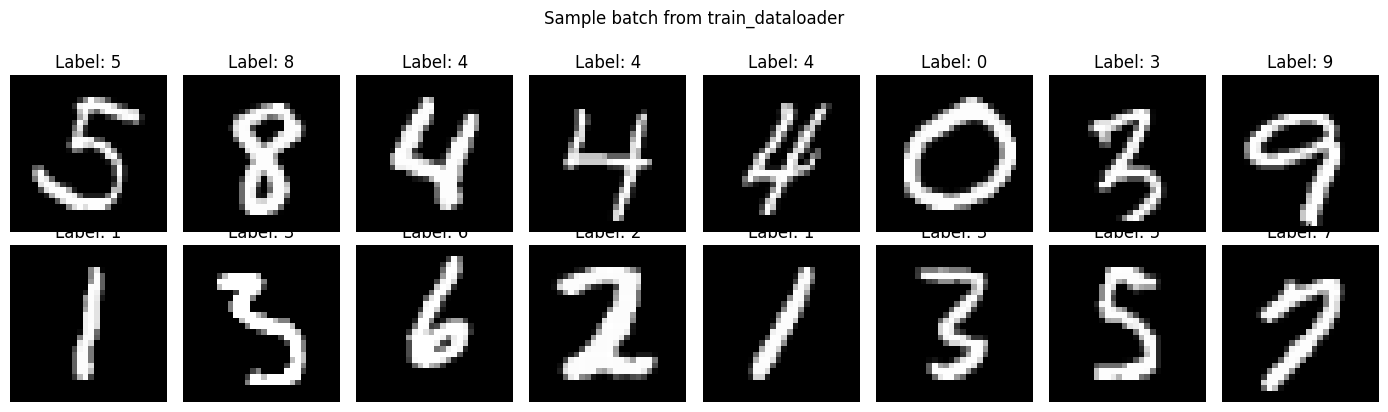

In [5]:
# Visualize a sample batch
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.suptitle("Sample batch from train_dataloader", y=1.02)
plt.tight_layout()
plt.show()

---
## Step 3 — LightningModule

A `LightningModule` is where your model lives. It extends `nn.Module` with a standard interface that the `Trainer` knows how to call.

### The key methods

| Method | Purpose |
|---|---|
| `__init__` | Define layers and hyperparameters |
| `forward` | Define the forward pass (inference) |
| `training_step` | Compute loss for one training batch |
| `validation_step` | Compute metrics for one validation batch |
| `test_step` | Compute metrics for one test batch |
| `configure_optimizers` | Return optimizer(s) and scheduler(s) |

### What Lightning automates for you
- Calling `.zero_grad()`, `.backward()`, `.step()` in the right order
- Moving tensors to the right device (CPU/GPU)
- Aggregating metrics across batches
- Switching between `train()` and `eval()` mode

In [6]:
class MNISTClassifier(pl.LightningModule):
    """
    A simple feed-forward classifier for MNIST.
    
    Architecture: Input(784) -> FC(256) -> ReLU -> Dropout -> FC(128) -> ReLU -> Dropout -> FC(10)
    
    Args:
        input_size  : flattened image size (28*28 = 784)
        hidden_size : number of units in the hidden layers
        num_classes : number of output classes (10 digits)
        dropout     : dropout probability for regularization
        lr          : initial learning rate
    """
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, dropout=0.3, lr=1e-3):
        super().__init__()
        # save_hyperparameters stores all __init__ args in self.hparams
        # and also saves them to the checkpoint — useful for resuming training
        self.save_hyperparameters()

        self.model = nn.Sequential(
            nn.Flatten(),                            # [B, 1, 28, 28] -> [B, 784]
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)  # raw logits, no softmax
        )

    def forward(self, x):
        # forward() is used for inference (e.g. model(x) calls)
        # It should return the raw logits
        return self.model(x)

    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------
    def training_step(self, batch, batch_idx):
        """
        Called for every training batch.
        Must return a loss tensor (scalar).
        
        `batch`     : whatever your DataLoader yields — here (images, labels)
        `batch_idx` : the index of this batch within the epoch
        """
        x, y = batch
        logits = self(x)                            # calls forward()
        loss   = F.cross_entropy(logits, y)         # combines log_softmax + NLLLoss
        acc    = self._accuracy(logits, y)

        # self.log() sends the metric to the logger and progress bar
        # on_step=True  -> log at each batch
        # on_epoch=True -> also log the epoch-level average
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc',  acc,  on_step=False, on_epoch=True, prog_bar=True)
        return loss

    # ------------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------------
    def validation_step(self, batch, batch_idx):
        """
        Called for every validation batch.
        Lightning automatically disables gradients and sets eval() mode.
        """
        x, y   = batch
        logits = self(x)
        loss   = F.cross_entropy(logits, y)
        acc    = self._accuracy(logits, y)

        # prog_bar=True shows this metric in the live training progress bar
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  acc,  prog_bar=True)

    # ------------------------------------------------------------------
    # Testing
    # ------------------------------------------------------------------
    def test_step(self, batch, batch_idx):
        x, y   = batch
        logits = self(x)
        loss   = F.cross_entropy(logits, y)
        acc    = self._accuracy(logits, y)
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    # ------------------------------------------------------------------
    # Optimizer and Scheduler
    # ------------------------------------------------------------------
    def configure_optimizers(self):
        """
        Return a dict with 'optimizer' and optionally 'lr_scheduler'.
        Lightning calls this once before training starts.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

        # ReduceLROnPlateau: reduce LR by factor 0.5 if val_loss doesn't
        # improve for 3 epochs ('patience')
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',       # minimize val_loss
            factor=0.5,       # multiply LR by this factor
            patience=3,       # wait this many epochs before reducing
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss',   # metric the scheduler watches
                'interval': 'epoch',     # step the scheduler every epoch
                'frequency': 1
            }
        }

    # ------------------------------------------------------------------
    # Helper
    # ------------------------------------------------------------------
    def _accuracy(self, logits, y):
        preds = torch.argmax(logits, dim=1)
        return (preds == y).float().mean()


# Inspect the model
model = MNISTClassifier()
print(model)
print("\nHyperparameters:", model.hparams)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters()))

MNISTClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)

Hyperparameters: "dropout":     0.3
"hidden_size": 256
"input_size":  784
"lr":          0.001
"num_classes": 10

Total parameters: 235146


### Quick forward pass test
Before training, always verify the model runs without errors on a real batch.

In [7]:
x_sample, y_sample = next(iter(dm.train_dataloader()))
logits = model(x_sample)
print(f"Input shape  : {x_sample.shape}")
print(f"Output shape : {logits.shape}  (batch_size x num_classes)")
print(f"Sample logits: {logits[0].detach().numpy().round(3)}")

Input shape  : torch.Size([512, 1, 28, 28])
Output shape : torch.Size([512, 10])  (batch_size x num_classes)
Sample logits: [-0.174 -0.091  0.03  -0.052 -0.07   0.108  0.188  0.147 -0.061  0.013]


---
## Step 4 — Callbacks

Callbacks let you inject custom logic at specific points in the training loop **without modifying your model code**. Lightning includes several useful built-in callbacks.

### EarlyStopping
Stops training when a monitored metric stops improving. Prevents wasting compute and overfitting.

### ModelCheckpoint
Saves the model to disk whenever a monitored metric improves. Ensures you always have the best version, not just the last one.

### LearningRateMonitor
Logs the current learning rate at each epoch — essential when using a scheduler, so you can see when and how much the LR changed.

In [8]:
# Stop if val_loss doesn't improve for 5 consecutive epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
)

# Save the top-1 checkpoint based on val_acc
checkpoint_callback = ModelCheckpoint(
    dirpath='checkpoints/',
    filename='mnist-{epoch:02d}-{val_acc:.3f}',
    monitor='val_acc',
    mode='max',          # higher val_acc is better
    save_top_k=1,        # keep only the single best checkpoint
)

# Log the learning rate at each epoch
lr_monitor = LearningRateMonitor(logging_interval='epoch')

print("Callbacks configured.")

Callbacks configured.


---
## Step 5 — Logger

Loggers record all metrics you pass to `self.log()` and write them to disk. Lightning supports TensorBoard, Weights & Biases, MLflow, and more. We'll use `CSVLogger` — no external dependencies, easy to inspect.

In [9]:
logger = CSVLogger(save_dir='logs/', name='mnist_classifier')
print(f"Logs will be saved to: {logger.log_dir}")

Logs will be saved to: logs/mnist_classifier/version_7


In [10]:
import time

class TimingCallback(pl.Callback):
    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        self.t0 = time.time()

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        elapsed = time.time() - self.t0
        if batch_idx < 5:
            print(f"  Batch {batch_idx}: {elapsed*1000:.1f}ms")

trainer = pl.Trainer(
    max_epochs=1,
    accelerator='auto',
    precision='16-mixed',
    callbacks=[TimingCallback()],   # ← solo este callback
    logger=False,                   # ← sin logger
    deterministic=False,
    gradient_clip_val=1.0,
    enable_progress_bar=False
)
trainer.fit(model, datamodule=dm)

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture02/notebooks/4_full_project/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  235 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

  Batch 0: 253.7ms
  Batch 1: 6.3ms
  Batch 2: 5.0ms
  Batch 3: 4.9ms
  Batch 4: 9.5ms


`Trainer.fit` stopped: `max_epochs=1` reached.


---
## Step 6 — Trainer

The `Trainer` is the engine that orchestrates everything. You hand it your model, your data, your callbacks, and your logger — and call `.fit()`.

### Key Trainer arguments

| Argument | Purpose |
|---|---|
| `max_epochs` | Maximum number of training epochs |
| `accelerator` | `'cpu'`, `'gpu'`, `'tpu'`, `'auto'` |
| `callbacks` | List of callback objects |
| `logger` | Logger instance |
| `log_every_n_steps` | How often to log step-level metrics |
| `deterministic` | Use deterministic CUDA ops for reproducibility |
| `gradient_clip_val` | Clip gradient norms to prevent exploding gradients |

In [11]:
# Re-initialize a fresh model and data module
pl.seed_everything(42, workers=True)

model = MNISTClassifier(lr=1e-3)
dm    = MNISTDataModule(batch_size=64, num_workers=2)

trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    precision='16-mixed',
    callbacks=[early_stopping, checkpoint_callback, lr_monitor],
    logger=logger,
    log_every_n_steps=10,
    deterministic=False,
    gradient_clip_val=1.0,
    enable_progress_bar=False
)

print("Trainer ready. Starting training...")
trainer.fit(model, datamodule=dm)

Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Trainer ready. Starting training...


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  235 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

---
## Step 7 — Testing

`trainer.test()` evaluates on the test set using the best checkpoint saved during training (if you pass `ckpt_path='best'`). This ensures you report performance from the best model, not the last one.

In [12]:
# Evaluate on the test set using the best checkpoint
test_results = trainer.test(model, datamodule=dm, ckpt_path='best')
print("\nTest results:", test_results)

Restoring states from the checkpoint path at /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture02/notebooks/4_full_project/checkpoints/mnist-epoch=17-val_acc=0.983.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture02/notebooks/4_full_project/checkpoints/mnist-epoch=17-val_acc=0.983.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9829999804496765     │
│         test_loss         │    0.07621914893388748    │
└───────────────────────────┴───────────────────────────┘


Test results: [{'test_loss': 0.07621914893388748, 'test_acc': 0.9829999804496765}]


---
## Step 8 — Inspecting the Training Logs

The `CSVLogger` writes a `metrics.csv` file. Let's load it and plot the training curves.

In [13]:
import os
import glob

# Find the latest log directory
csv_files = glob.glob('logs/mnist_classifier/version_*/metrics.csv')
latest_csv = sorted(csv_files)[-1]
print(f"Reading from: {latest_csv}")

metrics = pd.read_csv(latest_csv)
print(metrics.columns.tolist())
metrics.head(10)

Reading from: logs/mnist_classifier/version_7/metrics.csv
['epoch', 'lr-Adam', 'step', 'test_acc', 'test_loss', 'train_acc', 'train_loss_epoch', 'train_loss_step', 'val_acc', 'val_loss']


,epoch,lr-Adam,step,test_acc,test_loss,train_acc,train_loss_epoch,train_loss_step,val_acc,val_loss
0,NaN,0.001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,9,NaN,NaN,NaN,NaN,1.676077,NaN,NaN
2,0.0,NaN,19,NaN,NaN,NaN,NaN,1.064344,NaN,NaN
3,0.0,NaN,29,NaN,NaN,NaN,NaN,0.723895,NaN,NaN
4,0.0,NaN,39,NaN,NaN,NaN,NaN,0.858181,NaN,NaN
5,0.0,NaN,49,NaN,NaN,NaN,NaN,0.538807,NaN,NaN
6,0.0,NaN,59,NaN,NaN,NaN,NaN,0.480389,NaN,NaN
7,0.0,NaN,69,NaN,NaN,NaN,NaN,0.519160,NaN,NaN
8,0.0,NaN,79,NaN,NaN,NaN,NaN,0.470244,NaN,NaN
9,0.0,NaN,89,NaN,NaN,NaN,NaN,0.715484,NaN,NaN


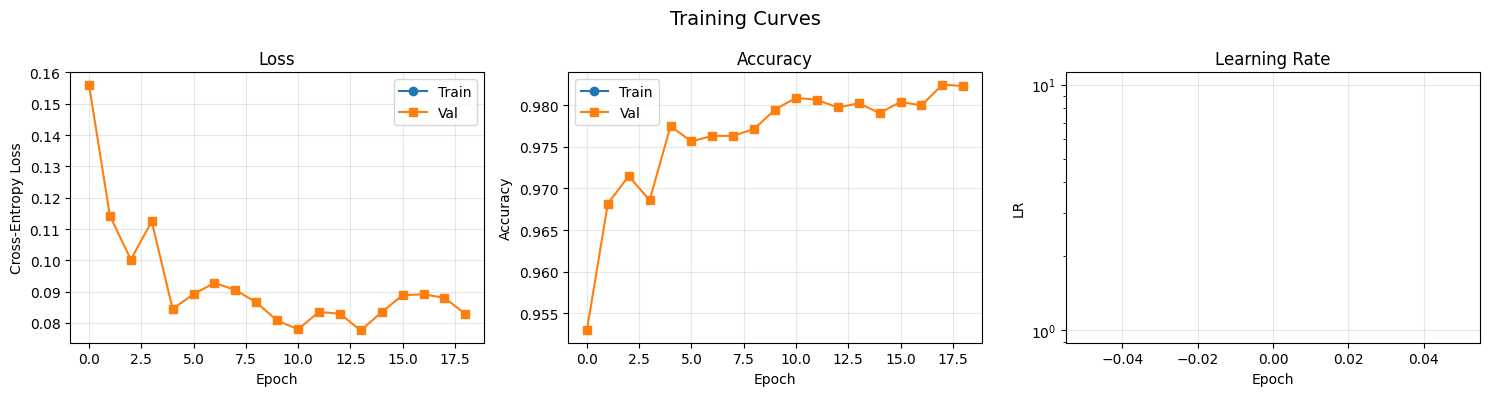

In [14]:
# Separate epoch-level metrics (they share the same 'epoch' index)
epoch_metrics = metrics.dropna(subset=['val_loss'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epoch_metrics['epoch'], epoch_metrics['train_loss_epoch'], label='Train', marker='o')
axes[0].plot(epoch_metrics['epoch'], epoch_metrics['val_loss'],         label='Val',   marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epoch_metrics['epoch'], epoch_metrics['train_acc'], label='Train', marker='o')
axes[1].plot(epoch_metrics['epoch'], epoch_metrics['val_acc'],   label='Val',   marker='s')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
if 'lr-Adam' in epoch_metrics.columns:
    axes[2].plot(epoch_metrics['epoch'], epoch_metrics['lr-Adam'], marker='o', color='green')
    axes[2].set_title('Learning Rate')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 9 — Loading a Checkpoint and Running Inference

A checkpoint saved by `ModelCheckpoint` contains the model weights **and** the hyperparameters (because we used `save_hyperparameters()`). This means you can reconstruct the full model from just the checkpoint file.

In [15]:
best_ckpt = checkpoint_callback.best_model_path
print(f"Best checkpoint: {best_ckpt}")
print(f"Best val_acc   : {checkpoint_callback.best_model_score:.4f}")

# Reconstruct the model from the checkpoint
loaded_model = MNISTClassifier.load_from_checkpoint(best_ckpt)
loaded_model.eval()  # switch to inference mode
print("\nLoaded model hparams:", loaded_model.hparams)

Best checkpoint: /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture02/notebooks/4_full_project/checkpoints/mnist-epoch=17-val_acc=0.983.ckpt
Best val_acc   : 0.9825

Loaded model hparams: "dropout":     0.3
"hidden_size": 256
"input_size":  784
"lr":          0.001
"num_classes": 10


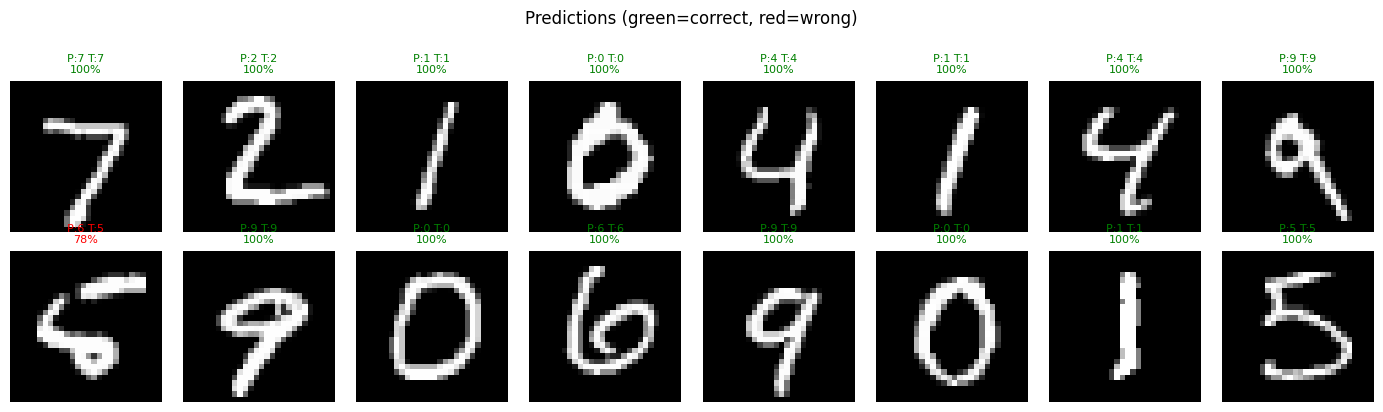

In [17]:
# Run inference on a test batch
dm.setup(stage='test')
test_batch = next(iter(dm.test_dataloader()))
test_images, test_labels = test_batch

with torch.no_grad():
    logits = loaded_model(test_images.to("cuda"))
    preds  = torch.argmax(logits, dim=1)
    probs  = F.softmax(logits, dim=1)

# Visualize predictions
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i].squeeze(), cmap='gray')
    pred_label = preds[i].item()
    true_label = test_labels[i].item()
    confidence = probs[i, pred_label].item()
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"P:{pred_label} T:{true_label}\n{confidence:.0%}", color=color, fontsize=8)
    ax.axis('off')
plt.suptitle("Predictions (green=correct, red=wrong)", y=1.02)
plt.tight_layout()
plt.show()

---
## Step 10 — Comparing Multiple Runs

One of Lightning's strengths is making it easy to run experiments systematically. Here we train with two different learning rates and compare the results.

In [ ]:
results = {}

for lr in [1e-2, 1e-3]:
    pl.seed_everything(42, workers=True)

    run_model = MNISTClassifier(lr=lr)
    run_logger = CSVLogger(save_dir='logs/', name=f'lr_{lr}')

    run_trainer = pl.Trainer(
        max_epochs=10,
        accelerator='auto',
        callbacks=[EarlyStopping(monitor='val_loss', patience=3)],
        logger=run_logger,
        enable_progress_bar=True,
        log_every_n_steps=10
    )

    run_trainer.fit(run_model, datamodule=dm)
    test_res = run_trainer.test(run_model, datamodule=dm, verbose=False)
    results[f'lr={lr}'] = test_res[0]['test_acc']
    print(f"lr={lr}  ->  test_acc={results[f'lr={lr}']:.4f}")

print("\nSummary:", results)

---
## Summary

Here is the full picture of what you built and why each piece matters:

```
pl.seed_everything(42)          # Reproducibility
        │
        ▼
MNISTDataModule                 # All data logic in one place
  ├── prepare_data()            # Download once
  ├── setup()                   # Split + transform
  └── *_dataloader()            # Efficient batching
        │
        ▼
MNISTClassifier (LightningModule)
  ├── forward()                 # Pure inference
  ├── training_step()           # Loss + logging
  ├── validation_step()         # Metrics + logging
  ├── test_step()               # Final evaluation
  └── configure_optimizers()    # Adam + ReduceLROnPlateau
        │
        ▼
Trainer
  ├── EarlyStopping             # Stop when not improving
  ├── ModelCheckpoint           # Save best model
  ├── LearningRateMonitor       # Log LR changes
  └── CSVLogger                 # Persist all metrics
```

### What to explore next

- **Convolutional network**: swap the `nn.Sequential` in `MNISTClassifier` with a CNN — the Lightning structure stays identical
- **Other schedulers**: try `CosineAnnealingLR` or `OneCycleLR` in `configure_optimizers`
- **Weights & Biases**: replace `CSVLogger` with `WandbLogger` for richer experiment tracking
- **Multi-GPU**: add `devices=2, strategy='ddp'` to the Trainer — no other code changes needed
- **Custom callbacks**: subclass `pl.Callback` and override hooks like `on_epoch_end` or `on_train_start`